# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)   # sets the default figure size for all Matplotlib plots to 9 inches wide × 4 inches tall.
plt.rcParams['axes.spines.top'] = False   # Hides the top border (spine) of the plot frame.
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [2]:
def classify_number(n):
    # YOUR CODE HERE
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif n <= 10:
        return "small positive"
    else:
        return "large positive"

# Tests
assert classify_number(-5) == "negative"            # If all conditions are true → nothing is printed (assertions are silent when passing). If any condition is false → AssertionError is raised, and the program stops.
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [3]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

# 1. word_count dict using a loop
word_count = {}
for w in words:
    if w in word_count:
        word_count[w] += 1
    else:
        word_count[w] = 1

# 2. unique_words set
unique_words = set(words)

# 3. long_words list comprehension: words with more than 5 characters
long_words = [w for w in words if len(w) > 5]

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [4]:
# 1.3 Exceptions
def safe_divide(a, b):
    # Check types first to raise TypeError
    if not (isinstance(a, (int, float)) and isinstance(b, (int, float))):        # isinstance(a, (int, float)): Returns True if a is of type int or float, otherwise False.
        raise TypeError("Inputs must be numeric")                                # TypeError : Raised when an operation is applied to an object of inappropriate type (e.g., adding string and integer).
    try:                                                                         # try-except : Allows you to catch and handle errors gracefully.
        return a / b
    except ZeroDivisionError:
        return None

# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [5]:
# 1.4 Functions & Lambdas
def apply_twice(f, x):
    return f(f(x))

triple = lambda x: x * 3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [6]:
# Part 2 — NumPy

# 2.1 Array Creation & Shapes
arr1d = np.arange(12)                     # integers 0 to 11
arr2d = arr1d.reshape(3, 4)               # shape (3,4)
arr3d = arr1d.reshape(2, 2, 3)            # shape (2,2,3)

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [7]:
# 2.2 Indexing & Slicing
row2 = arr2d[1, :]          # slicing; second row (index 1)
col3 = arr2d[:, 2]          # third column (index 2)
sub  = arr2d[1:, 2:]        # 1: → rows from index 1 to the end (second row onward),     2: → columns from index 2 to the end (third column onward) → extracts bottom-right submatrix.
gt7  = arr2d[arr2d > 7]     # boolean indexing; Creates a 1D array containing only the elements of arr2d that are greater than 7.



# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [8]:
# 2.3 Operations & Dot Product
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C  = A * B                     # element-wise product
D  = A @ B                     # matrix multiplication
dp = np.dot([1,2,3], [4,5,6]) # dot product of vectors → 1*4+2*5+3*6 = 32
E  = A * 3                     # scalar multiplication

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓


---
## Part 3 — Pandas

In [9]:
# Part 3 — Pandas

# Load dataset (provided)
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [10]:
# 3.1 DataFrames vs Series
salary_series = df['salary']                    # Series
name_dept_df  = df[['name', 'department']]      # DataFrame

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [11]:
# 3.2 iloc & loc
iloc_result = df.iloc[2:5, 0:3]          # rows 2,3,4 (indices 2,3,4); cols 0,1,2
loc_result  = df.loc[[5,6], ['name', 'salary']]   # index labels 5 and 6

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)

3.2 passed ✓


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [12]:
# 3.3 Filtering & Group By
senior_eng = df[(df['department'] == 'Engineering') & (df['salary'] > 90000)]

dept_stats = df.groupby('department')[['salary', 'performance']].mean()
dept_stats = dept_stats.sort_values('salary', ascending=False)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,salary,performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


### 3.4 Handling Missing Data

1. Identify which columns have missing values and how many → print a summary.
2. Fill missing `salary` with the **median salary** → `df_filled`
3. Fill missing `age` with the **mean age** (rounded to nearest int).
4. Drop rows where `performance` is missing.
5. Confirm no nulls remain.

In [13]:
# 3.4 Handling Missing Data
print("Missing values before:")
print(df.isnull().sum()) # prints sum of no of columns which are null in df

df_filled = df.copy()
# Fill salary with median salary
median_salary = df_filled['salary'].median()
df_filled['salary'].fillna(median_salary, inplace=True)

# Fill age with mean age (rounded to nearest int)
mean_age = round(df_filled['age'].mean())
df_filled['age'].fillna(mean_age, inplace=True)

# Drop rows where performance is missing
df_filled.dropna(subset=['performance'], inplace=True)

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


/tmp/ipykernel_38210/2937047690.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filled['salary'].fillna(median_salary, inplace=True)
/tmp/ipykernel_38210/2937047690.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

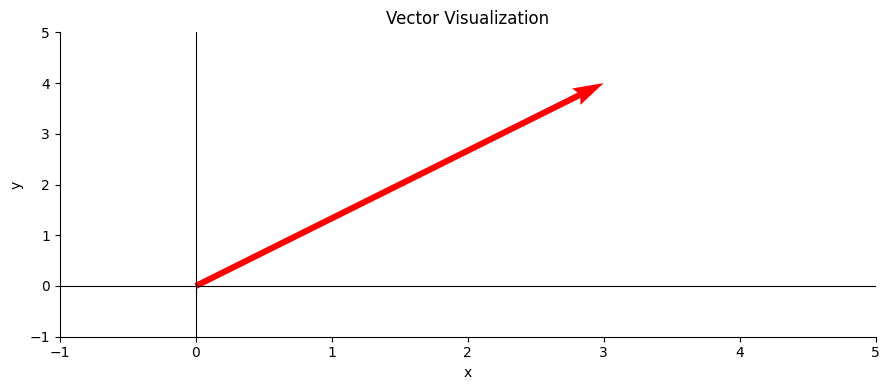

4.1 passed ✓  |v| = 5.0


In [14]:
# Part 4 — Linear Algebra

# 4.1 Vectors & Matrices as Data
v = np.array([3, 4])
norm_v = np.linalg.norm(v)          # L2 norm = sqrt(3^2+4^2) = 5   # linalg → linear algebra submodule of NumPy (contains matrix/vector operations).
                                    #norm → function that computes the magnitude (Euclidean length, L2) of a vector or matrix. # (v) → the input argument – a 1D array (vector) whose Euclidean norm is calculated

M = np.random.rand(3, 3)            # any 3x3 matrix (here random uniform)

# Plot vector as arrow from origin
fig, ax = plt.subplots()  # fig → figure object (the whole canvas), ax → axes object (the plotting area)

ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='r')
# ax.quiver → quiver refers to a specialized type of 2D plot used to visualize vector fields, say, method to draw an arrow (vector) on the axes,
# (0, 0 → starting point X, Y coordinates (origin),
# v[0]= 3, v[1]= 4 → arrow direction (X, Y components of vector v), angles='xy' → arrow angle is determined by the data coordinates (not screen pixels),
# scale_units='xy' → scaling is done relative to the X/Y data units, scale=1 → no extra scaling; length = vector magnitude in data units,
# color='r' → arrow colour: red
# Alternative (default): angles='uv' (or not specifying) interprets angles in screen/device units – the arrow direction can look distorted if the plot has unequal scaling
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5) # set X‑axis limits from -1 to 5
ax.set_xlabel('x'); ax.set_ylabel('y') # semicolon ; allows writing two separate statements on one line.
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
# ax.axhline(0) → draw a horizontal line at Y = 0.
# ax.axvline(0) → draw a vertical line at X = 0.
# color='k' → colour black ('k' is shorthand).
# lw=0.8 → line width = 0.8 points.
plt.tight_layout(); plt.show()
# plt.tight_layout() → automatically adjust subplot spacing to prevent overlap.
# plt.show() → display the plot on screen.



assert abs(norm_v - 5.0) < 1e-9  # 1 × 10⁻⁹
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [15]:
# 4.2 Matrix Operations in Practice
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ   = P + Q
scalar3P = 3 * P
PQ       = P @ Q
QP       = Q @ P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]
Eigenvector verification passed ✓


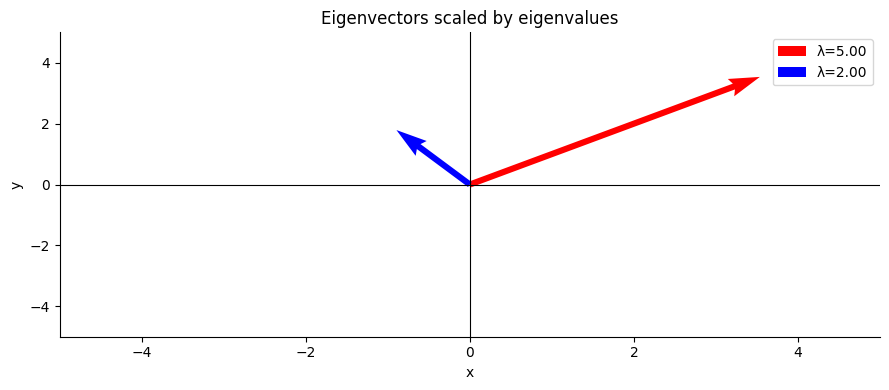

4.3 passed ✓


In [16]:
# 4.3 Eigenvalues & Eigenvectors
A = np.array([[4, 1], [2, 3]], dtype=float)
eigenvalues, eigenvectors = np.linalg.eig(A)   # eigenvectors as columns, eig → function that computes eigenvalues and eigenvectors of a square matrix, (A) → input matrix A (must be square).

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")
# eigenvector (columns):
# [[x1 y1],
# [x2, y2]]

# Verification part
# Verify Av = λv for each eigenpair
for i in range(len(eigenvalues)):
    lam = eigenvalues[i] # current eigenvalue (λ) for index i
    v = eigenvectors[:, i] # all rows (:), column i → the eigenvector corresponding to lam
    Av = A @ v #  matrix‑vector multiplication (lhs of eigen equation: A·v)
    lam_v = lam * v # scalar multiplication of eigenvalue with eigenvector (rhs: λ·v).
    assert np.allclose(Av, lam_v), f"Failed for eigenvalue {lam}" # checks that all elements are close (checks whether Av (matrix A times eigenvector v) is numerically equal to lam_v, allowing small floating‑point errors
print("Eigenvector verification passed ✓")

# Plot both eigenvectors scaled by their eigenvalues
fig, ax = plt.subplots()
origin = np.array([0, 0]) # Arrow starting point (origin)
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i] * eigenvalues[i]   # This makes the arrow length represent how much the matrix stretches that direction
    ax.quiver(origin[0], origin[1], v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color=['r','b'][i], label=f'λ={eigenvalues[i]:.2f}')   # color= red for first eigenvector, blue for second, label= shows legend
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8) # k- black color
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Eigenvectors scaled by eigenvalues')
ax.legend()
plt.tight_layout(); plt.show()

print("4.3 passed ✓")

**Geometric Explanation (4.3):**

> An eigenvector of a matrix is a non‑zero vector whose direction remains unchanged when multiplied by the matrix. The corresponding eigenvalue tells how much the vector is stretched (if |λ|>1) or squished (if |λ|<1) – a negative eigenvalue would reflect the direction. Geometrically, the matrix acts as a linear transformation that scales eigenvectors by their eigenvalues; all other vectors are transformed in a way that can be expressed as a combination of these stretching directions.

### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In [17]:
# 4.4 SVD & Dimensionality Reduction
np.random.seed(42) # random: random number generation, seed(42) → sets the random seed to 42 so results are reproducible.
X = np.random.randn(4, 3) # generates a 4‑row, 3‑column matrix filled with random numbers from the standard normal distribution (mean 0, variance 1).

U, S, Vt = np.linalg.svd(X, full_matrices=False) # np.linalg.svd → function to compute the Singular Value Decomposition, full_matrices=False → returns “economy‑size” SVD (smaller, more efficient for tall/wide matrices),
# U has shape (4, 3), S shape (3,), Vt shape (3, 3)

# Reconstruct X from SVD: X = U @ diag(S) @ Vt
X_reconstructed = U @ np.diag(S) @ Vt

# Rank‑1 approximation: keep only largest singular value
S_rank1 = np.zeros_like(S) #S_rank1 → array for rank‑1 approximation, np.zeros_like(S) → creates an array of zeros with the same shape and data type as S.
S_rank1[0] = S[0]  # S_rank1[0] → first element (index 0) of S_rank1, S[0] → first (largest) singular value from original S
X_approx = U @ np.diag(S_rank1) @ Vt # np.diag(S) creates a diagonal matrix from the singular values.

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")  # Prints the three singular values
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"  #  checks that all elements are close within an absolute tolerance 1e-10.
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 8.01e-16
Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

> *In SVD, the matrix U contains left singular vectors (principal component scores), S contains singular values (square roots of eigenvalues of XᵀX), and Vᵀ contains right singular vectors (principal component directions). For PCA, the right singular vectors (rows of Vᵀ) are the principal components – they are the directions of maximum variance in the data when centered. The singular values indicate how much variance each component explains.*

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


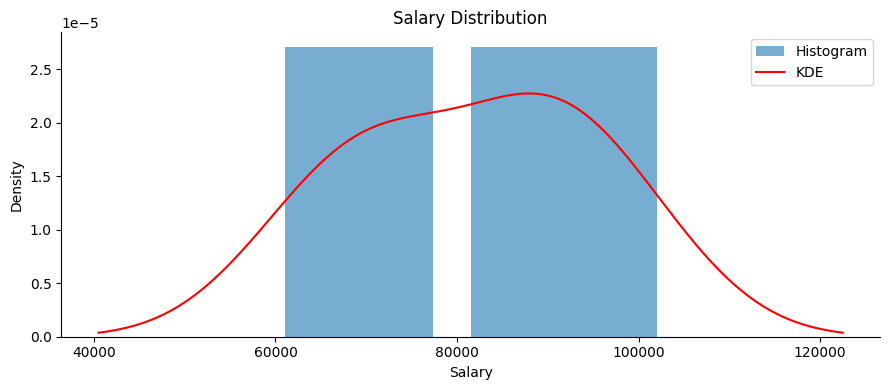

In [18]:
# Part 5 — Statistics

# 5.1 Descriptive vs Inferential Statistics
salary = df_filled['salary']

mean_s   = salary.mean()
median_s = salary.median()
std_s    = salary.std()
min_s    = salary.min()
max_s    = salary.max()
iqr_s    = np.percentile(salary, 75) - np.percentile(salary, 25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram + KDE
fig, ax = plt.subplots()
ax.hist(salary, bins=10, density=True, alpha=0.6, label='Histogram') # Histogram, bins=10 – divides the data range into 10 equal‑width intervals (bins).
# density=True – normalises the histogram so the total area of all bars equals 1. This makes it a probability density rather than raw counts, allowing comparison with the KDE.
# alpha=0.6 – sets transparency (0 = fully transparent, 1 = opaque). Helps see overlapping elements.

salary.plot.kde(ax=ax, color='r', label='KDE')  # line colour red, KDE: kernel density estimate: A smooth, continuous estimate of the probability density function (PDF) of salaries. It's created by placing a small “kernel” (e.g., Gaussian) at each data point and summing them, then normalising.
ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
ax.legend()
plt.tight_layout(); plt.show()

**Definitions (5.1):**

- **Population:** The entire set of individuals or observations of interest.
Example: All employees of a company (e.g., 10 employees in the dataset).

- **Sample:** A subset of the population selected for measurement, often because the population is too large to study entirely.
Example: If the company had 1000 employees, a random selection of 100 employees would be a sample.

- **Descriptive statistic:** A summary measure that describes a feature of a dataset (e.g., mean, median, standard deviation).
Example: The mean salary of these 10 employees is a descriptive statistic.

- **Inferential statistic:** A method that uses sample data to draw conclusions about a population.
Example: Using the mean salary of a sample of 100 employees (out of 1000) to estimate the mean salary of all 1000 employees.

### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

In [19]:
# 5.2 Hypothesis Testing
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

# One-sample t-test (two-tailed by default). compare Engineering salaries to overall mean
t_stat, p_value_two_tailed = stats.ttest_1samp(eng_salaries, overall_mean)

# Convert to one-tailed (since we hypothesize Engineering mean > overall mean)
if eng_salaries.mean() > overall_mean:
    p_value_one_tailed = p_value_two_tailed / 2
else:
    p_value_one_tailed = 1.0  # effect opposite to direction, p-value = 1 - (two-tailed/2) but typically >0.5

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}") # t-statistic (one‑sample t‑test), t= (x bar- μ0)/(s/ n^1/2 )
# x bar= mean of engineering salaries
# μ0 = overall mean salary (hypothesised population mean)
# s = sample standard deviation of engineering salaries
# n = number of engineers
print(f"p-value (one-tailed): {p_value_one_tailed:.4f}") # step 4,5
# Steps to Calculate T Value One Sample T-Test:-
# Step 1: State a null hypothesis and an alternative hypothesis. The null hypothesis assumes that the sample mean and the known population mean (μ) are equal, while the other assumes that the sample mean is different from the population mean.
# Step 2: Define values for the level of significance (α) and the degree of freedom (df). The degree of freedom equals (n - 1) for this case.
# Step 3: Calculate the t-value using the formula stated above by putting all the known values of the sample mean (x̄), sample standard deviation (σ), the population mean (μ), and the sample size (n).
# Step 4: Determine the associated p-value with the t-value using a t-distribution table.
# Step 5: Compare the p-value to the level of significance. If the p-value is less than the level of significance, reject the null hypothesis and conclude that the sample mean is significantly different from the population mean. Otherwise, conclude that there is no significant difference between the sample mean and the population mean.

print(f"Reject H0 at α=0.05? {p_value_one_tailed < 0.05}")

# Pearson correlation between salary and years_exp (no directional hypothesis → keep two-tailed)
r, r_pval_two_tailed = stats.pearsonr(df_filled['salary'], df_filled['years_exp']) # Pearson correlation coefficient, r =sigma (xi-xbar).(yi-ybar)/ (  ( sigma (xi-xbar)^2) )^1/2 . ( sigma (yi-ybar)^2) )^1/2  )
# r = cov(x,y)/sx.sy  ; cov(x,y) = sample covariance, sx, sy = sample standard deviations
# r_pval = p-value for Pearson correlation
# The p‑value for Pearson correlation (r_pval) tests the null hypothesis that the true population correlation coefficient ρ = 0 (no linear relationship). It is calculated as follows:
# 1. Compute the test statistic (under the null hypothesis):
# t= r⋅ ( (n-2)/(1-r^2) )^1/2  ;
# r = sample correlation coefficient
# n = number of data pairs
# 2. Determine the p‑value from the t‑distribution with  n−2 degrees of freedom: p-value=2×P(T>∣t∣)
# (two‑tailed test, because the alternative hypothesis is  ρ≠0).

print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval_two_tailed:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value (one-tailed): 0.0140
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

- H₀: The mean salary of Engineering employees equals the overall company mean salary.

- H₁: The mean salary of Engineering employees is different from the overall mean.

- Conclusion: p-value = 0.0140 < 0.05 → reject H₀. There is statistically significant evidence that Engineering salaries differ from the company average (they are higher). The Pearson correlation (0.0485, p=0.9015) shows a strong positive linear relationship between salary and years of experience.

### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [20]:
# 5.3 Error Metrics (from scratch)
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2     # p = number of independent (predictor) variables (features)

mae    = np.mean(np.abs(y_true - y_pred))
mse    = np.mean((y_true - y_pred)**2)
rmse   = np.sqrt(mse)
ss_res = np.sum((y_true - y_pred)**2) # residual sum of squares: uses predicted y
ss_tot = np.sum((y_true - np.mean(y_true))**2) # total sum of squares: uses y mean
r2     = 1 - ss_res/ss_tot # Represents the proportion of variance in the dependent variable that is explained by the independent variable(s). Range: (−∞,1]. Closer to 1 means better fit.
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1) # Adjusted R‑squared: Penalises the addition of unnecessary predictors. Increases only if a new predictor improves the model more than expected by chance. Always ≤ R2. Useful for comparing models with different numbers of predictors.
# adj_r2 = 1 - ( (1-r2)*(n-1)/(n-p-1) )

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [21]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(0) # sets the random seed to 0 so results are reproducible.
s1 = np.random.normal(0, 1, 200)  # draws 200 samples from a normal distribution with mean 0 and standard deviation 1.
s2 = np.random.exponential(1, 200) #  draws 200 samples from an exponential distribution with scale λ = 1 (rate = 1).

# KS test comparing each against standard normal CDF, ie, compares empirical CDF to theoretical CDF, https://www.tutorialspoint.com/statistics/kolmogorov_smirnov_test.htm
ks_s1 = stats.kstest(s1, 'norm', args=(0,1))   # s1 should be close to normal, stats.kstest → performs the KS test comparing an empirical distribution with a theoretical one,
# 'norm' → theoretical distribution is normal, args=(0,1) → parameters of the normal: mean 0, std 1
ks_s2 = stats.kstest(s2, 'norm', args=(0,1))   # exponential is far from normal

# statistic = maximum vertical distance between the two CDFs
# p-value = probability of observing such a large D under H0 (sample comes from theoretical distribution)
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")
# # How KS statistic is calculated:
# D_n = sup_x | F_n(x) - F(x) |
#   - F_n(x) = empirical CDF: (# of sample values ≤ x) / n
#   - F(x) = theoretical CDF (e.g., standard normal)
#   - sup = supremum (maximum difference over all x)

# p-value: derived from the Kolmogorov distribution; for large n,
#   P(√n * D_n ≤ d) ≈ 1 - 2 * sum_{k=1}^∞ (-1)^{k-1} * e^{-2k^2 d^2}
#   The `kstest` function uses an approximation or exact algorithm.

# detail: KS statistic (D) calculation for a sample against a theoretical distribution:
# 1. Sort the sample data (x₁, x₂, …, xₙ) in ascending order.
# 2. Compute the empirical CDF: Fₙ(x) = (number of sample values ≤ x) / n
# 3. Compute the theoretical CDF: F(x) (e.g., standard normal CDF using mean=0, std=1)
# 4. At each sample point x_i, calculate:
#       D⁺ = max over i of | Fₙ(x_i) - F(x_i) |
#       D⁻ = max over i of | Fₙ(x_{i-1}) - F(x_i) |  (jump at left limit)
# 5. KS statistic D = max(D⁺, D⁻)
#
# Formula: D = supₓ | Fₙ(x) - F(x) |
#
# Example: For n=200, the `kstest` function:
#   - Sorts the 200 sample values.
#   - At each point, computes difference between empirical and theoretical CDFs.
#   - Finds the maximum absolute difference.
#   - Returns that as `statistic`.

# ADF test on non-stationary series
# Null Hypothesis (H₀): The timeseries has a unit root (non-stationary)
# Alternative Hypothesis (H₁): The series is stationary
# Δyt = α + β.t + γ.yt−1 + ∑θiΔy(t−i) + ϵt
t = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)   # linear trend + noise → non-stationary

# Maths of differencing:
# If y_t = α + β*t + ε_t (trend + stationary noise), then:
# Δy_t = y_t - y_{t-1} = β + (ε_t - ε_{t-1}) → becomes stationary (constant mean, constant variance).
# ADF test on Δy_t should reject the unit root null (p < 0.05).

# ADF test regression equation:
# Δy_t = α + β*t + γ*y_{t-1} + δ_1*Δy_{t-1} + ... + δ_p*Δy_{t-p} + ε_t
# Null hypothesis H0: γ = 0 (unit root, non-stationary)
# Alternative H1: γ < 0 (stationary)
# Test statistic = γ_hat / se(γ_hat) and compared to Dickey-Fuller critical values.
# p-value is derived from the empirical distribution of this statistic.


adf_result = adfuller(ts)   # returns (statistic, p-value, ...)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")   # typically False

# Difference once: compute successive differences
ts_diff = np.diff(ts)         # y'_t = y_t - y_{t-1}
adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

PSI: 1.9099
Shift severity: Major


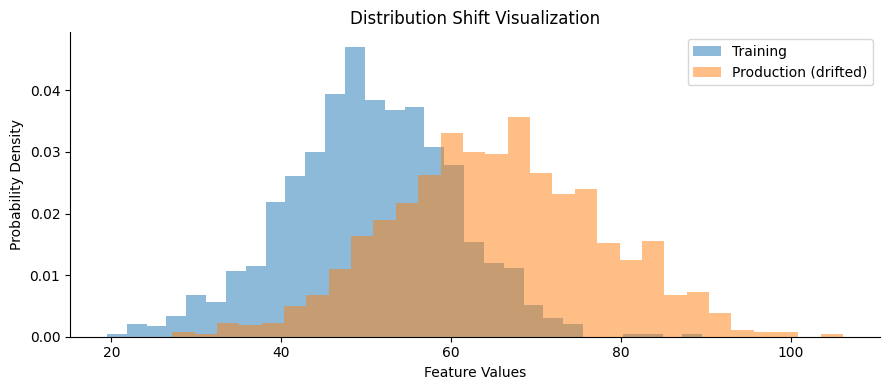

In [22]:
def compute_psi(expected, actual, bins=10):  # Population Stability Index (PSI)
    # Compute PSI between two distributions
    # Use quantile bins based on the combined distribution to have consistent bin edges
    # expected → baseline distribution (e.g., training data).
    # actual → new distribution (e.g., production data).

    # Compute common min/max, then create bins+1 evenly spaced edges.
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    bin_edges = np.linspace(min_val, max_val, bins+1)

    # Expected counts per bin: Count how many observations fall into each bin for expected and actual
    exp_counts, _ = np.histogram(expected, bins=bin_edges)
    act_counts, _ = np.histogram(actual, bins=bin_edges)

    # Convert counts to proportions (probabilities)
    exp_pct = exp_counts / exp_counts.sum()         # pct is shorthand for proportion (or percentage)
    act_pct = act_counts / act_counts.sum()

    # Add small epsilon to avoid log(0)
    eps = 1e-10
    exp_pct = np.clip(exp_pct, eps, 1)   # np.clip ensures values are at least eps and at most 1.
    act_pct = np.clip(act_pct, eps, 1)

    # PSI = sum( (actual_pct - expected_pct) * ln(actual_pct/expected_pct) )    # sum or sigma: same
    psi = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)      # Training distribution: N(50, 10)
drift_dist = np.random.normal(65, 12, 1000)     # Production (drifted) distribution: N(65, 12) – mean increased, variance increased

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

# Plot both distributions
fig, ax = plt.subplots()
ax.hist(train_dist, bins=30, alpha=0.5, density=True, label='Training')
ax.hist(drift_dist, bins=30, alpha=0.5, density=True, label='Production (drifted)')
# Add axis labels
ax.set_xlabel('Feature Values')
ax.set_ylabel('Probability Density')
ax.legend()
ax.set_title('Distribution Shift Visualization')
plt.tight_layout()
plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- Concept drift: Change in the relationship between input features and the target variable (e.g., buying behaviour changes after a pandemic).

- Covariate drift: Change in the distribution of input features, while the relationship to target remains stable.

- PSI < 0.1: No significant shift.

- PSI 0.1–0.2: Minor shift, may need monitoring.

- PSI > 0.2: Major shift, model retraining recommended.

- Retraining trigger example: When PSI exceeds 0.2 for two consecutive weeks.

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [23]:
total = 10
red, blue, green = 4, 3, 3

p_red   = red / total
p_blue  = blue / total
p_green = green / total

# Joint: P(red first AND blue second) without replacement
# P(red first) * P(blue second | red first)
p_red_then_blue = (red / total) * (blue / (total - 1))

# Conditional: P(blue second | red first) = blue / (total-1)
p_blue_given_red = blue / (total - 1)

# Independence check: if draws were independent, P(blue|red) should equal P(blue)
# They are not equal → dependent
independent = (p_blue_given_red == p_blue)   # False

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

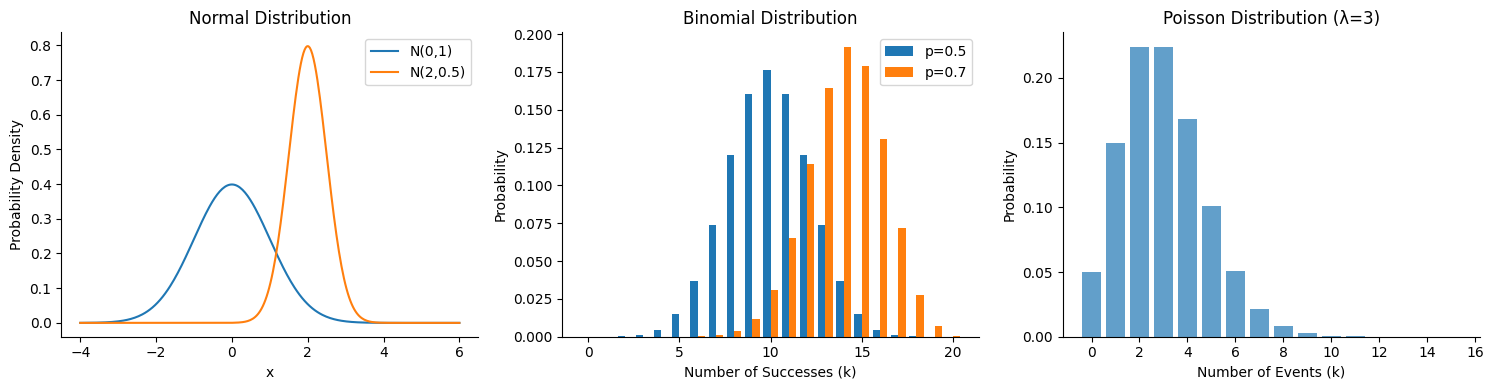

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Normal ──────────────────────────────────────────
x = np.linspace(-4, 6, 300)   # Generate 300 equally spaced x values from -4 to 6 for smooth curve

# Normal PDF formula: f(x | μ, σ) = 1/(σ√(2π)) * exp( - (x-μ)² / (2σ²) )
pdf_norm1 = stats.norm.pdf(x, loc=0, scale=1)   # N(μ=0, σ=1)  (standard normal),  location parameter: For the normal distribution, it is the mean (μ) , scale parameter: For the normal distribution, it is the standard deviation (σ)
pdf_norm2 = stats.norm.pdf(x, loc=2, scale=0.5)   # N(μ=2, σ=0.5)  (narrower peak)

# Plot both curves on the first subplot (index 0)
axes[0].plot(x, pdf_norm1, label='N(0,1)')
axes[0].plot(x, pdf_norm2, label='N(2,0.5)')
axes[0].legend()   # Add legend to distinguish the two lines
axes[0].set_title('Normal Distribution')  # # Set title of the first subplot
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability Density')
## ML use case: Modelling continuous features (e.g., height, test scores) after standardisation.

# ── Binomial ────────────────────────────────────────
k = np.arange(0, 21) # # Possible number of successes: 0,1,2,...,20

# Binomial PMF formula: P(X=k) = C(n,k) * p^k * (1-p)^(n-k)
# where C(n,k) = n! / (k! (n-k)!), n
# n = number of trials (fixed, independent)
# k = number of successes (can be 0, 1, 2, …, n)
# p = probability of success on a single trial (constant)
# 1−p = probability of failure

pmf_binom_p5 = stats.binom.pmf(k, n=20, p=0.5)   # For n=20, p=0.5 (fair coin)
pmf_binom_p7 = stats.binom.pmf(k, n=20, p=0.7)   # For n=20, p=0.7 (biased coin)

# Second subplot: bar chart with two groups side by side
axes[1].bar(k-0.2, pmf_binom_p5, width=0.4, label='p=0.5')  # Shift bars left by 0.2 for p=0.5
axes[1].bar(k+0.2, pmf_binom_p7, width=0.4, label='p=0.7')  # Shift bars right by 0.2 for p=0.7
axes[1].legend()
axes[1].set_title('Binomial Distribution')
axes[1].set_xlabel('Number of Successes (k)')
axes[1].set_ylabel('Probability')
## ML use case: Binary classification with fixed number of trials (e.g., number of clicks out of 10 impressions).

# ── Poisson ─────────────────────────────────────────
# Possible counts: 0,1,...,15
k2 = np.arange(0, 16)

# Poisson PMF formula: P(X=k) = e^{-λ} * λ^k / k! ; used when events happen independently at a constant average rate λ.
# - P(X=k) : probability of observing exactly k events
# - k      : number of events (non-negative integer: 0,1,2,...)
# - λ      : average rate (mean number of events) per interval
# - e^{-λ} : exponential decay factor, ensures total probability sums to 1
# - λ^k    : weights by rate
pmf_pois = stats.poisson.pmf(k2, mu=3)

# Third subplot: bars with transparency 0.7
axes[2].bar(k2, pmf_pois, alpha=0.7)
axes[2].set_title('Poisson Distribution (λ=3)')
axes[2].set_xlabel('Number of Events (k)')
axes[2].set_ylabel('Probability')
## ML use case: Modelling count data (e.g., number of customer arrivals per minute, defects per batch).

plt.tight_layout()
plt.show()

### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

In [25]:
# 6.3 Bayes' Theorem
p_spam            = 0.30
p_free_given_spam = 0.80 # P("free" | Spam) = probability of seeing the word "free" in an email that is spam (likelihood)
p_free_given_ham  = 0.05  # ham = legitimate/ desired messages
p_ham             = 1 - p_spam

# P(free) = P(free|spam)P(spam) + P(free|ham)P(ham)
p_free = p_free_given_spam * p_spam + p_free_given_ham * p_ham

# Bayes: P(spam|free) = P(free|spam)P(spam) / P(free)
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    prior_ham = 1 - prior_spam
    p_word = p_word_given_spam * prior_spam + p_word_given_ham * prior_ham
    posterior = (p_word_given_spam * prior_spam) / p_word
    return posterior

pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

# ============================================================
# BAYES' THEOREM - FORMULA, STATEMENT, AND CONDITIONS
# ============================================================

# --- FORMULA ---
# P(A|B) = P(B|A) * P(A) / P(B)
# Where:
#   P(A|B) = posterior probability: probability of event A given B occurred
#   P(B|A) = likelihood: probability of event B given A occurred
#   P(A)   = prior probability: initial belief about A before seeing B
#   P(B)   = evidence: total probability of event B (normalising constant)

# --- STATEMENT ---
# Bayes' Theorem describes the probability of an event A occurring given that another event B has already occurred, based on prior knowledge of conditions that might be related to A.
# In words: Posterior = (Likelihood × Prior) / Evidence

# --- CONDITIONS FOR USE ---
# 1. Events A and B must be non-zero probability events (P(A) > 0, P(B) > 0).
# 2. P(B) is computed using the law of total probability: P(B) = P(B|A)·P(A) + P(B|¬A)·P(¬A); where ¬A is A does not occur
# 3. The theorem applies to both discrete and continuous probability spaces.
# *****4. For naive Bayes (multiple features), we add the conditional independence, ie assumption: P(B1, B2, ..., Bn | A) = ∏ P(Bi | A).

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | 0.30 |
| Likelihood | P(word \| Spam) | 0.80 |
| Evidence | P(word) | 0.2750 |
| Posterior | P(Spam \| word) | 0.8727 |

### 6.4 Central Limit Theorem

1. Define a population following an **exponential distribution** (λ=1, size=100,000).
2. Repeatedly draw samples of size `n=30` and record their means — do this 5,000 times.
3. Plot the histogram of sample means.
4. Overlay the **theoretical normal distribution** predicted by the CLT: μ = population mean, σ = population_std / sqrt(n).
5. Run a KS test to confirm the distribution of sample means is approximately normal.

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 1.0021, std: 0.1845
CLT predicted std: 0.1827



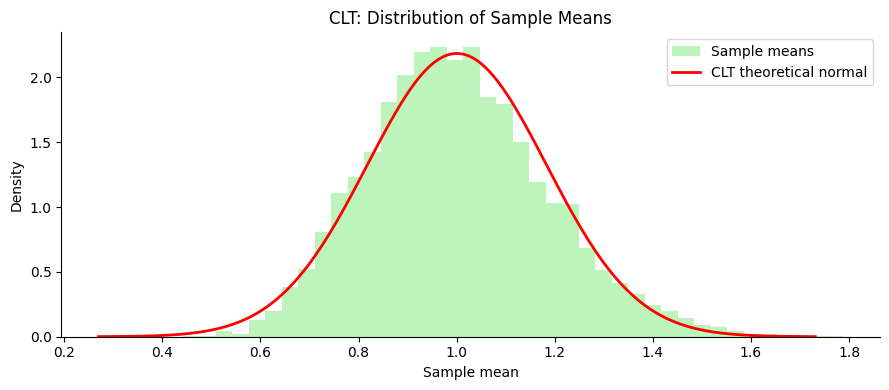

KS test p-value: 0.0054 → Approximately normal? False

Shapiro-Wilk Test:
Statistic: 0.9920
p-value : 0.0000
Approximately normal? False



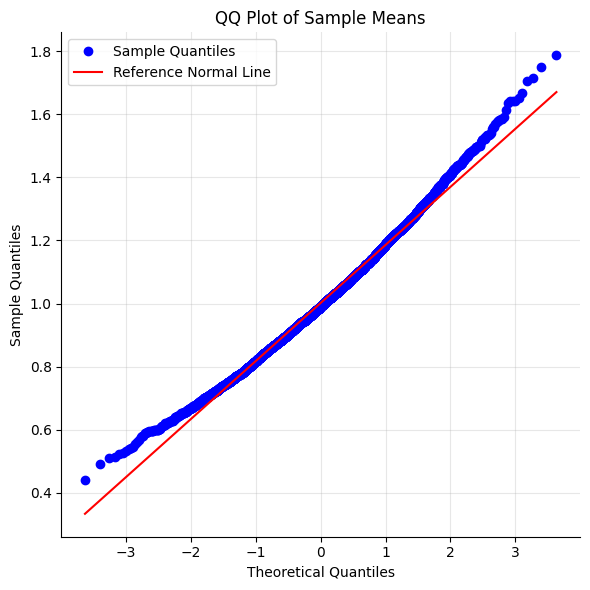

In [26]:
# 6.4 Central Limit Theorem: If you draw independent random samples of size n from any population (with finite mean μ and finite variance σ^2, then the sampling distribution (prob density vs conti var) of the sample mean approaches a normal
# distribution as n becomes large, regardless of the shape of the original population distribution.

np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)
# Exponential PDF: f(x) = (1/β) * e^(-x/β) for x ≥ 0, where β = scale = 1.0.
# Here scale = 1/λ (λ = rate). Mean = β = 1, variance = β² = 1.
# Population size: 100,000 observations

n_samples = 5000          # number of samples to draw
sample_size = 30          # each sample contains 30 observations

# --- Create an array of 5000 sample means ---
# List comprehension: for each of the 5000 iterations:
#   - np.random.choice(population, size=sample_size, replace=False)
#       Randomly select `sample_size` values from the population without replacement.
#   - .mean()   Compute the arithmetic mean of the selected sample.
# The outer np.array() converts the list of means into a NumPy array.
sample_means = np.array([
    np.random.choice(population, size=sample_size, replace=False).mean()
    for _ in range(n_samples)
])

# Population parameters
pop_mean = population.mean() # mean of the entire exponential population
pop_std  = population.std()

# CLT: The standard deviation of the sampling distribution of the mean (# Theoretical standard deviation of the sample means (standard error)) :
# population standard deviation divided by sqrt(sample size)
clt_std = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}") # bcz Central Limit Theorem predicts what the standard deviation of sample means should be theoretically.
print()

# Plot histogram of sample means and overlay the theoretical normal distribution
fig, ax = plt.subplots()
# Histogram with density=True normalises to probability density
ax.hist(sample_means, bins=40, density=True, alpha=0.6, color='lightgreen', label='Sample means') # Histogram of the 5000 sample means

# Theoretical normal distribution predicted by CLT:
# X̄ ~ N(μ, σ/√n) approximately for large n (here n=30, large enough).
# Generate 200 values from μ - 4*σ_x̄ to μ + 4*σ_x̄ (covers most of the density).
x = np.linspace(pop_mean - 4*clt_std, pop_mean + 4*clt_std, 200)
# Normal PDF: f(x) = 1/(σ_x̄ √(2π)) * exp(-(x-μ)²/(2 σ_x̄²))
pdf_clt = stats.norm.pdf(x, loc=pop_mean, scale=clt_std)
# Plot the theoretical curve in red, line width 2
ax.plot(x, pdf_clt, 'r-', lw=2, label='CLT theoretical normal')

ax.set_title('CLT: Distribution of Sample Means')
ax.set_xlabel('Sample mean')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

# Kolmogorov‑Smirnov test: compare sample means against a normal distribution, with mean = pop_mean and standard deviation = clt_std
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}") # Accept up to 5% chance of wrongly rejecting normality, ie, 95% confidence level (standard convention in statistics)

# -------------------------------------------------------------------
# Additional Normality Checks for CLT Demonstration
# -------------------------------------------------------------------

# Shapiro-Wilk Test
# H0: data follows a normal distribution
# H1: data does not follow a normal distribution
# Note:
# Shapiro test is officially recommended for sample sizes <= 5000.
# We use only first 5000 values (already exactly 5000 here).
shapiro_result = stats.shapiro(sample_means)
print("\nShapiro-Wilk Test:")
print(f"Statistic: {shapiro_result.statistic:.4f}")
print(f"p-value : {shapiro_result.pvalue:.4f}")
print(f"Approximately normal? {shapiro_result.pvalue > 0.05}")
print()


# -------------------------------------------------------------------
# QQ Plot (Quantile-Quantile Plot)
# If points lie close to the straight line,
# the distribution is approximately normal.
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(sample_means, dist="norm", plot=ax)
ax.set_title("QQ Plot of Sample Means")
# Add axis labels
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
# Optional grid for better readability
ax.grid(True, alpha=0.3)
# Add labels manually to plotted lines
ax.get_lines()[0].set_label("Sample Quantiles")
ax.get_lines()[1].set_label("Reference Normal Line")
# Show legend
ax.legend()

plt.tight_layout()
plt.show()

**CLT Reflection (6.4):**

> The Central Limit Theorem (CLT) matters because it ensures that the sampling distribution of the mean becomes approximately normal as sample size grows, even when the original population is not normal. This justifies the widespread use of parametric tests (e.g., t‑test, ANOVA, z‑test) that assume normality, allowing valid inference from sample statistics to population parameters in many practical situations. In machine learning, it underpins confidence intervals for evaluation metrics and enables the use of normal approximations in algorithms like linear regression and stochastic gradient descent.

## Interpretation of Normality Results

The histogram and QQ plot visually suggest that the distribution of sample means is approximately normal, which supports the Central Limit Theorem (CLT).

However, both the KS test and Shapiro-Wilk test return very small p-values (`< 0.05`), causing the statistical tests to reject perfect normality.

This happens because:

1. The original population follows an exponential distribution, which is highly right-skewed.

2. The sample size is `n = 30`, which makes the sampling distribution approximately normal, but not perfectly normal.

3. Statistical normality tests become extremely sensitive when the number of observations is large (here 5000 sample means).

4. Even very tiny deviations from an ideal normal distribution are detected by KS and Shapiro-Wilk tests, resulting in very small p-values.

Therefore:

- **Visually** → the distribution appears approximately normal.
- **Statistically** → tests detect small non-normal deviations.

This does **not** contradict the Central Limit Theorem because CLT guarantees **approximate normality**, not perfect normality.

---
## 🏁 Submission Checklist

Before submitting, verify:

- [ ] All `assert` blocks pass without errors
- [ ] All `# YOUR CODE HERE` cells are filled
- [ ] All markdown reflection cells are filled in your own words
- [ ] All plots render with labels and titles
- [ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`

In [27]:

# NOTE:-
# ====================================================================
# STATISTICAL METHODS IN ML PIPELINES: WHEN TO USE WHAT?
# ====================================================================
# This guide covers: ADF test, KS test, t-test, PSI, CLT
# For each: beginner → advanced applications, entrepreneurial use case,
# and clear differentiation from other methods.
# ====================================================================

# ------------------- 1. ADF (Augmented Dickey-Fuller) Test -------------------
# Purpose: Check if a time series is stationary (no unit root).
# When to use: Before applying models that assume stationarity (ARIMA, VAR, linear regression with time series).

# Beginner applications:
#   - Detect if stock prices are random walk (non-stationary) vs mean-reverting.
#   - Verify that residuals from a regression are stationary (no spurious correlation).
#   - Check inflation or GDP data before forecasting.

# Advanced applications:
#   - Unit root testing in cointegration analysis (e.g., pairs trading strategy).
#   - Pre-whitening for cross-correlation analysis.
#   - Testing for seasonal unit roots (Canova-Hansen test variant).

# Entrepreneurial application:
#   - **Algorithmic trading bot**: Before entering a mean-reversion strategy,
#     run ADF on the spread of two assets. If p-value < 0.05 → stationary spread
#     → pairs trade profitable. If non-stationary, avoid trade.
#   - **Energy demand forecasting**: Validate stationarity of hourly electricity
#     consumption after removing trend/seasonality; else model fails.

# When to use ADF vs others:
#   - vs KS: ADF is for time series (order matters); KS for i.i.d. distributions.
#   - vs t-test: t-test compares means (static); ADF tests temporal dependence.
#   - vs PSI: PSI monitors distribution shift over time; ADF tests unit root.
#   - vs CLT: CLT is asymptotic theory; ADF is a specific hypothesis test.

# ------------------- 2. KS (Kolmogorov-Smirnov) Test -------------------------
# Purpose: Compare two distributions (or one sample against a theoretical dist).
# When to use: Check if two samples come from the same distribution; test normality.

# Beginner applications:
#   - Validate if model residuals are normally distributed (against N(0,1)).
#   - Compare training and validation set distributions (feature drift).
#   - Test if a sample matches an expected theoretical distribution (e.g., uniform).

# Advanced applications:
#   - Two-sample KS test for detecting dataset shift in high-dimensional
#     projections (e.g., after PCA).
#   - Non-parametric comparison of survival curves (Kaplan-Meier).
#   - Goodness-of-fit for generative models (e.g., GAN output vs real data).

# Entrepreneurial application:
#   - **Credit scoring model monitoring**: Before deploying a model, run KS
#     between the training data and incoming production data (on each feature).
#     If KS statistic > threshold (e.g., 0.1), trigger retraining due to covariate shift.
#   - **A/B testing platform**: Use KS to check if the distribution of a
#     metric (e.g., session duration) differs significantly between control
#     and treatment groups – more sensitive than t-test for non-normal data.

# When to use KS vs others:
#   - vs t-test: t-test compares means only (sensitive to normality); KS compares
#     entire distribution (any shape) but less powerful for pure mean differences.
#   - vs ADF: KS for static distributions; ADF for time series stationarity.
#   - vs PSI: PSI is also for distribution shift but uses binning; KS is
#     continuous and more sensitive for small shifts. Use KS for precise
#     two-sample comparison; use PSI for monotonic monitoring (less sensitive to outliers).

# ------------------- 3. t-test (Student's t-test) ---------------------------
# Purpose: Compare the mean of one group to a known value (one-sample), or
# compare means of two groups (two-sample). Assumes approximate normality.

# Beginner applications:
#   - One-sample t-test: Does the average salary of engineers exceed the company
#     average? (as in your assignment)
#   - Two-sample t-test: Compare conversion rates between two website versions
#     (but careful – proportions require z-test; t-test works for large n).
#   - Paired t-test: Before-after effect of a training program on test scores.

# Advanced applications:
#   - Welch's t-test (unequal variances) for robust comparison.
#   - Multiple testing correction (Bonferroni, FDR) when running many t-tests.
#   - Linear regression t-test for individual coefficient significance.

# Entrepreneurial application:
#   - **E-commerce pricing experiment**: Randomly assign users to price A vs B.
#     Use two-sample t-test on average purchase value. If p < 0.05, roll out
#     the better price. Assumes CLT justifies normality (large sample).
#   - **Employee productivity analysis**: Compare productivity of remote vs
#     office workers using one-sample t-test against historical baseline.
#   - **Customer lifetime value (CLV) lift test**: After a marketing campaign,
#     compare mean CLV of exposed vs control group.

# When to use t-test vs others:
#   - vs KS: t-test only tests mean difference; KS tests whole distribution.
#     Use t-test when you have a specific hypothesis about the mean.
#   - vs ADF: t-test for cross-sectional (i.i.d.) data; ADF for time series.
#   - vs PSI: t-test for mean shift; PSI for overall distribution shift.
#   - vs CLT: t-test uses CLT to justify normality for sample means; CLT itself
#     is a theoretical result, not a test.

# ------------------- 4. PSI (Population Stability Index) ---------------------
# Purpose: Quantify how much a distribution has shifted (typically over time).
# When to use: Model monitoring – compare expected (training) vs actual (production)
# distributions for each feature or model score.

# Beginner applications:
#   - Check if the distribution of a numeric feature (e.g., age) changed between
#     training and new data. PSI > 0.2 indicates major shift → retrain.
#   - Monitor model output scores – if PSI high, the environment changed.
#   - Compare pre- and post-processing distributions in a data pipeline.

# Advanced applications:
#   - Multi-dimensional PSI using PCA projections.
#   - Adaptive PSI with dynamic binning (quantile or decision tree bins).
#   - Sequential PSI monitoring with EWMA control charts.

# Entrepreneurial application:
#   - **Loan default model in production**: Every week compute PSI on each
#     input feature (income, credit score, etc.) and on the model's probability
#     scores. Set up an alert: if any feature's PSI > 0.1, investigate;
#     if > 0.2, automatically schedule retraining. This prevents silent model decay.
#   - **Fraud detection system**: Monitor transaction amount distribution.
#     A sudden PSI shift may indicate a new fraud pattern or seasonal change.
#   - **Recommendation engine**: Track distribution of user engagement scores.
#     PSI helps detect concept drift before revenue drops.

# When to use PSI vs others:
#   - vs KS: PSI is less sensitive to small differences and more interpretable
#     for business monitoring (thresholds 0.1, 0.2). KS is more powerful for
#     small sample sizes. Use PSI for automated pipelines where you need a
#     simple stability score; use KS for statistical testing of equality.
#   - vs t-test: t-test only detects mean shift; PSI detects any shape change
#     (variance, skewness, multimodality).
#   - vs ADF: PSI for i.i.d. distribution shift; ADF for time series stationarity.

# ------------------- 5. CLT (Central Limit Theorem) --------------------------
# Purpose: Theoretical foundation – not a test, but a justification for using
# normal-based methods (t-test, confidence intervals) with large samples.

# When to use: Whenever you need to assume that the sampling distribution of
# the mean (or sum) is normal, regardless of the population distribution,
# as long as sample size is sufficiently large (n ≥ 30 is rule of thumb).

# Beginner applications:
#   - Justify using t-test for non-normal data (e.g., income distribution).
#   - Construct confidence intervals for average customer spend using normal
#     approximation (z-interval).
#   - Explain why bagging (bootstrap aggregating) works – averages of many models
#     become normal.

# Advanced applications:
#   - Asymptotic normality of maximum likelihood estimators (MLE).
#   - Delta method for approximating variance of transformed statistics.
#   - Theoretical basis for stochastic gradient descent convergence.
#   - Central limit theorem for dependent data (mixing sequences).

# Entrepreneurial application:
#   - **Risk management for investment portfolio**: CLT allows you to treat
#     the average daily return of a portfolio (with many assets) as normally
#     distributed, even if individual returns are heavy-tailed. Use this to
#     compute Value at Risk (VaR) using normal approximation.
#   - **Quality control in manufacturing**: Take samples of size 30 from a
#     production line (e.g., bottle fill weights). Even if the individual
#     weights are skewed, the sample mean is approximately normal, so you can
#     use standard control charts (Shewhart) to detect shifts.
#   - **Survey analysis** (e.g., customer satisfaction): For sample size >30,
#     use normal-based confidence intervals for average rating, no need to
#     assume original ratings are normal.

# When to use CLT vs others:
#   - CLT is not a test; it's a theoretical justification for using normal
#     approximations. You don't "run" CLT; you rely on it when designing
#     experiments or statistical tests.
#   - vs t-test: t-test incorporates CLT but adds small-sample correction
#     (using t-distribution). With large n, t-test and z-test (based on CLT) agree.
#   - vs KS: KS does not rely on CLT; it works for any n.
#   - vs ADF: ADF uses its own asymptotic distribution (Dickey-Fuller), not normal.
#   - vs PSI: PSI uses no asymptotic normality.

# ====================================================================
# QUICK DECISION TREE FOR YOUR PIPELINE
# ====================================================================
#
# 1. Is your data a time series? → Use ADF test to check stationarity.
#
# 2. Do you need to compare two distributions (any difference)?
#    → Use KS test (small samples, exact) or PSI (monitoring, interpretable thresholds).
#
# 3. Is your hypothesis about a mean difference (e.g., A/B test)?
#    → Use t-test (or z-test for proportions). For large n, CLT justifies it.
#
# 4. Are you monitoring a production model for distribution shift?
#    → Use PSI per feature and on model scores. Set alerts at 0.1 (minor) and 0.2 (major).
#
# 5. Do you need to justify that sample mean is normal to compute confidence intervals?
#    → Invoke CLT (requires n ≥ 30 and independent samples).
#
# ====================================================================

